In [ ]:
# !pip install torch torchvision -q

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

In [ ]:
class RetinopathyDataset(Dataset):
    def __init__(self, df, features, transform=None):
        self.df = df
        self.features = features
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")
        label = int(row["DR_ICDR"])

        tabular = row[self.features].values.astype(np.float32)
        tabular = torch.tensor(tabular)

        if self.transform:
            img = self.transform(img)

        return img, tabular, label

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [ ]:
train_dataset = RetinopathyDataset(train_df, selected_features, transform=train_transform)
val_dataset   = RetinopathyDataset(val_df, selected_features, transform=val_transform)
test_dataset  = RetinopathyDataset(test_df, selected_features, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
class MultiModalModel(nn.Module):
    def __init__(self, num_tabular_features, num_classes):
        super().__init__()

        self.cnn = models.densenet121(pretrained=True)
        self.cnn_features = self.cnn.classifier.in_features
        self.cnn.classifier = nn.Identity()

        self.tabular_net = nn.Sequential(
            nn.Linear(num_tabular_features, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(self.cnn_features + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, image, tabular):
        img_feat = self.cnn(image)
        tab_feat = self.tabular_net(tabular)

        combined = torch.cat([img_feat, tab_feat], dim=1)
        out = self.classifier(combined)

        return out

In [ ]:
num_classes = len(train_df["DR_ICDR"].unique())

model = MultiModalModel(
    num_tabular_features=len(selected_features),
    num_classes=num_classes
).to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 206MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
from tqdm import tqdm

epochs = 1

for epoch in range(epochs):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader)

    for images, tabular, labels in loop:
     images = images.to(device)
     tabular = tabular.to(device)
     labels = labels.to(device)

     optimizer.zero_grad()
     outputs = model(images, tabular)
     loss = criterion(outputs, labels)
     loss.backward()
     optimizer.step()

     total_loss += loss.item()
     loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
     loop.set_postfix(loss=loss.item())

    print(f"✅ Epoch {epoch+1} finished | Total Loss: {total_loss:.4f}")

Epoch [1/1]: 100%|██████████| 407/407 [14:34<00:00,  2.15s/it, loss=0.33]

✅ Epoch 1 finished | Total Loss: 142.9501


In [ ]:
def evaluate(loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, tabular, labels in loader:
            images = images.to(device)
            tabular = tabular.to(device)

            outputs = model(images, tabular)
            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())

    return np.array(preds), np.array(targets)

In [ ]:
val_preds, val_targets = evaluate(val_loader)

print("Validation Accuracy:", accuracy_score(val_targets, val_preds))
print(classification_report(val_targets, val_preds))

Validation Accuracy: 0.946078431372549
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1544
           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00        44
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        27

    accuracy                           0.95      1632
   macro avg       0.19      0.20      0.19      1632
weighted avg       0.90      0.95      0.92      1632



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
test_preds, test_targets = evaluate(test_loader)

print("Test Accuracy:", accuracy_score(test_targets, test_preds))
print(classification_report(test_targets, test_preds))

Test Accuracy: 0.9190858554663373
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1488
           1       0.00      0.00      0.00        23
           2       0.00      0.00      0.00        50
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00        52

    accuracy                           0.92      1619
   macro avg       0.18      0.20      0.19      1619
weighted avg       0.84      0.92      0.88      1619



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
mis_idx = np.where(test_preds != test_targets)[0]
print(" Number of wrong predictions:", len(mis_idx))

 Number of wrong predictions: 131


### **4 XAI TECHNIQUES**

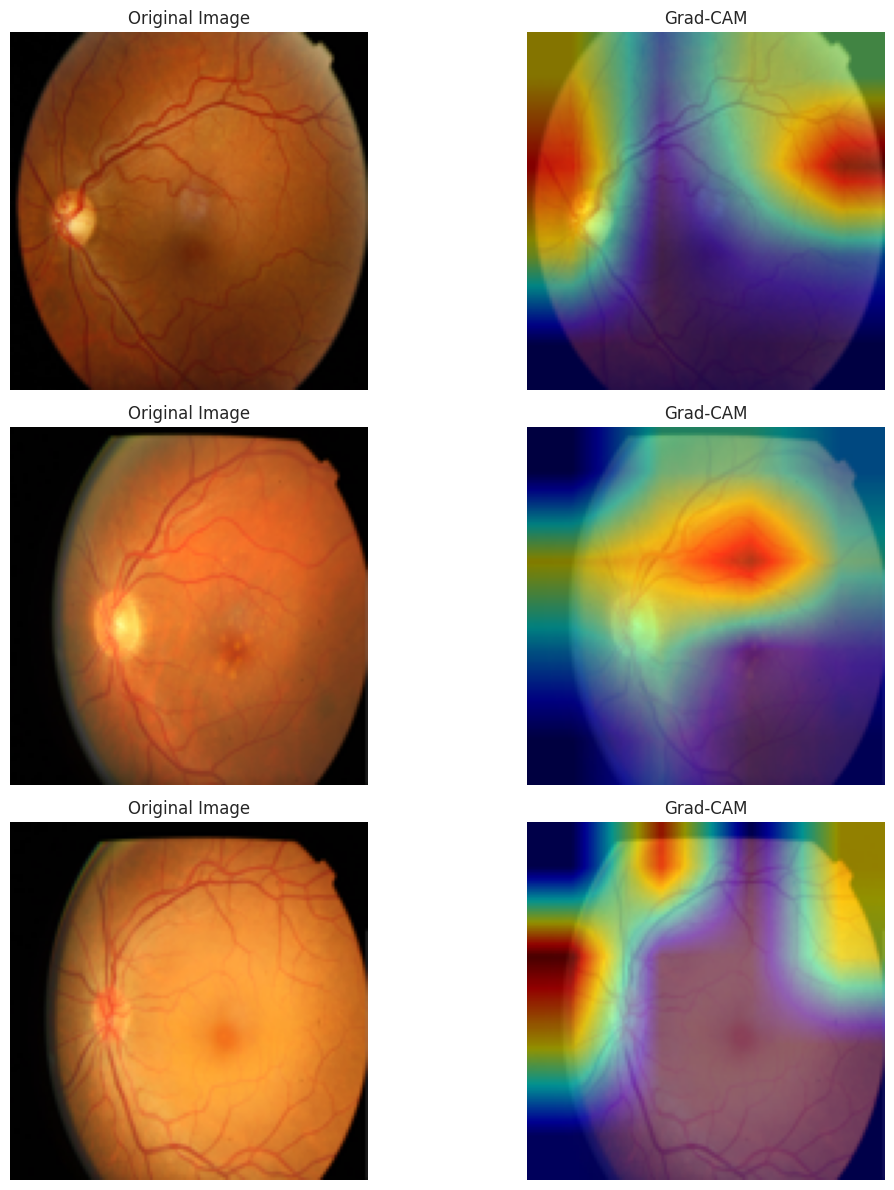

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image


class CNNWrapper(torch.nn.Module):
    def __init__(self, cnn):
        super().__init__()
        self.cnn = cnn

    def forward(self, x):
        return self.cnn.features(x).mean(dim=[2,3])

model.eval()

wrapped_model = CNNWrapper(model.cnn).to(device)

target_layers = [model.cnn.features[-1]]
cam = GradCAM(model=wrapped_model, target_layers=target_layers)


samples = test_df.sample(3, random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 12))

for i in range(3):
    row = samples.iloc[i]

    img = Image.open(row["image_path"]).convert("RGB")
    input_tensor = val_transform(img).unsqueeze(0).to(device)

    rgb_img = np.array(img.resize((128,128))) / 255.0

    targets = [ClassifierOutputTarget(int(row["DR_ICDR"]))]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)


    plt.subplot(3, 2, i*2 + 1)
    plt.imshow(img.resize((128,128)))
    plt.title("Original Image")
    plt.axis("off")


    plt.subplot(3, 2, i*2 + 2)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis("off")

plt.tight_layout()
plt.show()

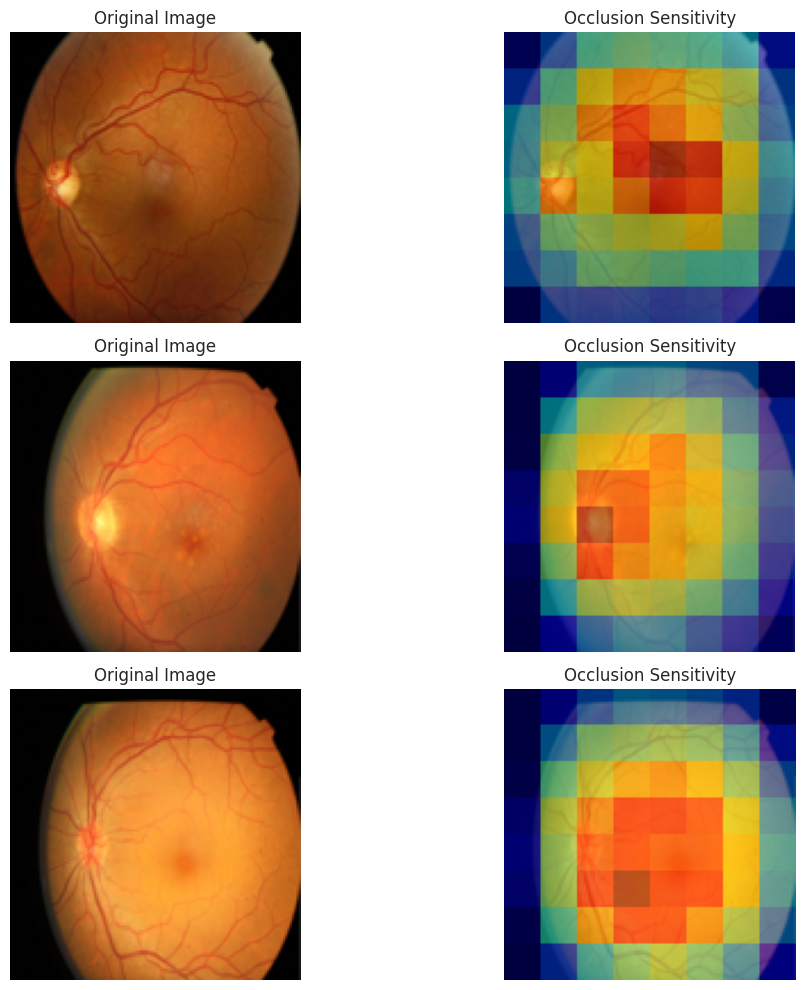

In [ ]:


import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

model.eval()

patch_size = 16
samples = test_df.sample(3, random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 10))

def predict_single(x):
    x = torch.tensor(x).permute(0,3,1,2).float().to(device)
    with torch.no_grad():
        out = model.cnn(x)
    return out.cpu().numpy()

for i in range(3):

    row = samples.iloc[i]

    img = Image.open(row["image_path"]).convert("RGB").resize((128,128))
    img_np = np.array(img)

    heatmap = np.zeros((128,128))


    for x in range(0, 128, patch_size):
        for y in range(0, 128, patch_size):

            occluded = img_np.copy()
            occluded[x:x+patch_size, y:y+patch_size] = 0

            orig = predict_single(img_np[np.newaxis, ...])
            new  = predict_single(occluded[np.newaxis, ...])

            heatmap[x:x+patch_size, y:y+patch_size] = np.abs(orig - new).mean()

    plt.subplot(3, 2, i*2 + 1)
    plt.imshow(img_np)
    plt.title("Original Image")
    plt.axis("off")


    plt.subplot(3, 2, i*2 + 2)
    plt.imshow(img_np)
    plt.imshow(heatmap, cmap="jet", alpha=0.5)
    plt.title("Occlusion Sensitivity")
    plt.axis("off")

plt.tight_layout()
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 18.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

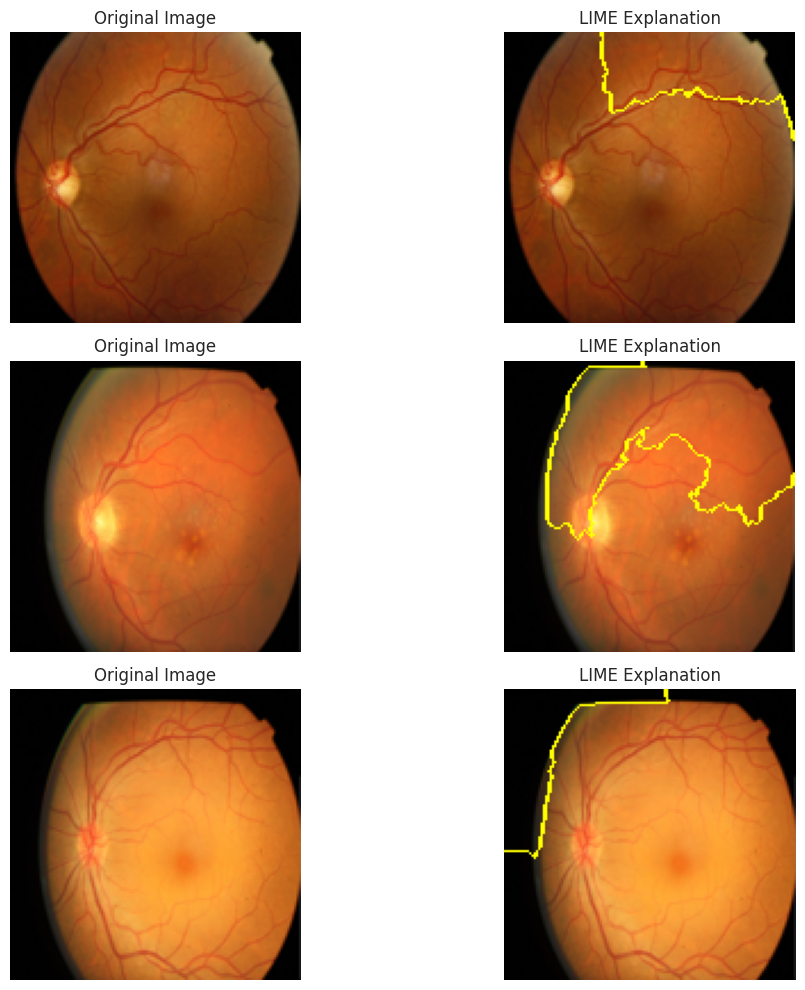

In [ ]:


!pip install lime -q

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from lime import lime_image
from skimage.segmentation import mark_boundaries

model.eval()

explainer = lime_image.LimeImageExplainer()

def batch_predict(images):
    images = torch.tensor(images).permute(0,3,1,2).float().to(device)
    with torch.no_grad():
        outputs = model.cnn(images)
    return outputs.cpu().numpy()

samples = test_df.sample(3, random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 10))

for i in range(3):

    row = samples.iloc[i]

    img = Image.open(row["image_path"]).convert("RGB").resize((128,128))
    img_np = np.array(img)

    explanation = explainer.explain_instance(
        img_np,
        batch_predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    lime_img = mark_boundaries(temp / 255.0, mask)

    plt.subplot(3, 2, i*2 + 1)
    plt.imshow(img_np)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(3, 2, i*2 + 2)
    plt.imshow(lime_img)
    plt.title("LIME Explanation")
    plt.axis("off")

plt.tight_layout()
plt.show()

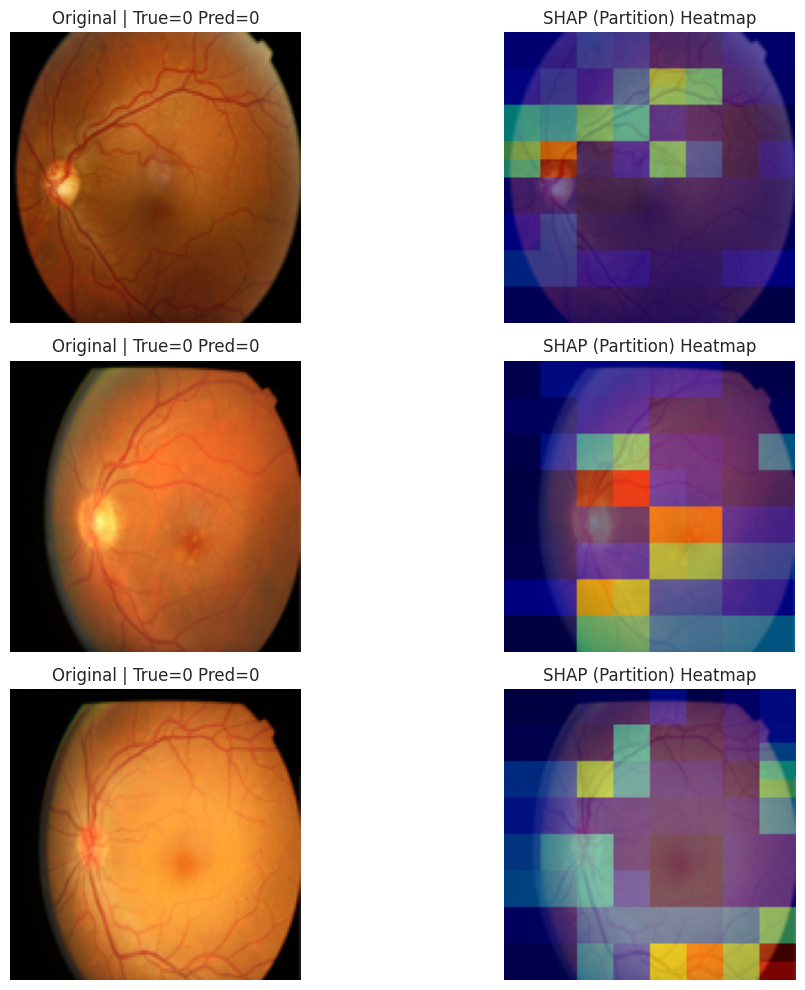

In [ ]:
!pip install shap -q

import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

model.eval()

fixed_tab = torch.tensor(
    train_df[selected_features].mean(axis=0).values.astype(np.float32),
    device=device
)

def predict_fn(x_np):
    x_np = x_np.astype(np.float32)
    if x_np.max() > 1.0:
        x_np = x_np / 255.0

    x_t = torch.from_numpy(x_np).permute(0, 3, 1, 2).to(device)

    if x_t.shape[-1] != 128 or x_t.shape[-2] != 128:
        x_t = torch.nn.functional.interpolate(x_t, size=(128, 128), mode="bilinear", align_corners=False)

    tab = fixed_tab.unsqueeze(0).repeat(x_t.size(0), 1)

    with torch.no_grad():
        logits = model(x_t, tab)
        probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()

masker = shap.maskers.Image("blur(16,16)", (128, 128, 3))
explainer = shap.Explainer(predict_fn, masker, output_names=[str(c) for c in sorted(train_df["DR_ICDR"].unique())])

samples = test_df.sample(3, random_state=42).reset_index(drop=True)
imgs = []

for _, row in samples.iterrows():
    img = Image.open(row["image_path"]).convert("RGB").resize((128, 128))
    imgs.append(np.array(img).astype(np.float32) / 255.0)

imgs = np.stack(imgs, axis=0)

shap_values = explainer(imgs, max_evals=300, batch_size=8)

pred_probs = predict_fn(imgs)
pred_classes = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(12, 10))
for i in range(len(imgs)):
    sv = shap_values.values[i, :, :, :, pred_classes[i]]  # H,W,C
    heat = np.mean(np.abs(sv), axis=2)

    plt.subplot(len(imgs), 2, 2*i + 1)
    plt.imshow(imgs[i])
    plt.title(f"Original | True={int(samples.iloc[i]['DR_ICDR'])} Pred={pred_classes[i]}")
    plt.axis("off")

    plt.subplot(len(imgs), 2, 2*i + 2)
    plt.imshow(imgs[i])
    plt.imshow(heat, cmap="jet", alpha=0.5)
    plt.title("SHAP (Partition) Heatmap")
    plt.axis("off")

plt.tight_layout()
plt.show()